In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

plt.style.use("../aigues-de-catalunya.mplstyle")

# Catalan Open Data exploration

## Data load

### Agència Catalana de l'Aigua
The Agència Catalana de l'Aigua has [documentation](https://aca.gencat.cat/es/laigua/consulta-de-dades/dades-obertes/dades-obertes-temps-real/) pertaining to the public APIs that allow for retrieving structured data on water in Catalonia.

| Datos       | Catálogo                                                                                                                                      | Últimos datos recogidos                                                                                          |
|-------------|-----------------------------------------------------------------------------------------------------------------------------------------------|-------------------------------------------------------------------------------------------------------------------|
| Embalses    | https://aplicacions.aca.gencat.cat/sdim2/apirest/catalog?componentType=embassament                                                           | https://aplicacions.aca.gencat.cat/sdim2/apirest/data/EMBASSAMENT-EST                                            |
| Aforos      | https://aplicacions.aca.gencat.cat/sdim2/apirest/catalog?componentType=aforament                                                             | https://aplicacions.aca.gencat.cat/sdim2/apirest/data/AFORAMENT-EST                                              |
| Pluviómetros| https://aplicacions.aca.gencat.cat/sdim2/apirest/catalog?componentType=pluviometre                                                           | https://aplicacions.aca.gencat.cat/sdim2/apirest/data/PLUVIOMETREACA-EST                                         |
| Piezómetros | https://aplicacions.aca.gencat.cat/sdim2/apirest/catalog?componentType=piezometre                                                            | https://aplicacions.aca.gencat.cat/sdim2/apirest/data/PIEZOMETRE-EST                                             |

### Portal de Transparència de Catalunya
Then, there is the water consumption data from the [Portal de Transparència de Catalunya](https://analisi.transparenciacatalunya.cat/Medi-Ambient/Consum-d-aigua-a-Catalunya-per-comarques/2gws-ubmt/about_data).

In [2]:
import pandas as pd
from sodapy import Socrata

# Unauthenticated client only works with public data sets. Note 'None'
# in place of application token, and no username or password:
client = Socrata("analisi.transparenciacatalunya.cat", None)

# Example authenticated client (needed for non-public datasets):
# client = Socrata(analisi.transparenciacatalunya.cat,
#                  MyAppToken,
#                  username="user@example.com",
#                  password="AFakePassword")

# First 2000 results, returned as JSON from API / converted to Python list of
# dictionaries by sodapy.
consumption_data_raw = client.get("2gws-ubmt", limit=2000)

# Convert to pandas DataFrame
consumption_data = pd.DataFrame.from_records(consumption_data_raw)

In [3]:
# normalize dtypes
consumption_data = consumption_data.astype({
    'any' : int,
    'codi_comarca' : int,
    'poblaci' : int,
    'dom_stic_xarxa' : int,
    'activitats_econ_miques_i' : int,
    'total' : int,
    'consum_dom_stic_per_c_pita' : float
})

consumption_data.head()

,any,codi_comarca,comarca,poblaci,dom_stic_xarxa,activitats_econ_miques_i,total,consum_dom_stic_per_c_pita
0,2024,1,"ALT CAMP, L'",46338,1588721,2602737,4191458,93.93
1,2024,2,"ALT EMPORDÀ, L'",148856,7532744,4005563,11538307,138.64
2,2024,3,"ALT PENEDÈS, L'",114215,4217395,2723893,6941288,101.16
3,2024,4,"ALT URGELL, L'",21214,1007067,1299444,2306511,130.06
4,2024,5,"ALTA RIBAGORÇA, L'",4002,466835,429561,896396,319.59


### Institut Cartogràfic i Geològic de Catalunya

The data here was obtained in the [ICGC website](https://www.icgc.cat/ca/Geoinformacio-i-mapes/Dades-i-productes/Geoinformacio-cartografica/Divisions-administratives). It refers to the geographical coordinates of the boundaries between catalan "comarques".

In [4]:
import geopandas as gpd

# Path to your zipped GeoJSON file
zip_path = 'zip:///home/rcortini/work/personal_projects/aigues-de-catalunya/data/divisions-administratives-v2r1-20250101.zip!divisions-administratives-v2r1-comarques-5000-20250101.json'

# Load the GeoJSON directly from the zip
comarques = gpd.read_file(zip_path)

# Check the loaded data
comarques.head()

,CODICOMAR,NOMCOMAR,CAPCOMAR,AREAC5000,geometry
0,01,Alt Camp,Valls,537.8597,"MULTIPOLYGON (((1.47594 41.47798, 1.47459 41.4..."
1,02,Alt Empordà,Figueres,1356.9070,"MULTIPOLYGON (((3.22338 42.23682, 3.22337 42.2..."
2,03,Alt Penedès,Vilafranca del Penedès,592.5553,"MULTIPOLYGON (((1.6169 41.5126, 1.61666 41.512..."
3,04,Alt Urgell,la Seu d'Urgell,1446.6785,"MULTIPOLYGON (((1.31941 41.99157, 1.31775 41.9..."
4,05,Alta Ribagorça,el Pont de Suert,427.2234,"MULTIPOLYGON (((0.8795 42.6314, 0.87928 42.631..."


In [5]:
# some Comarca have weird names, we fix it
def fix_comarca(comarca):
    if comarca == "Moianès":
        return "MOIANÈS"
    return comarca.split(',')[0]

consumption_data['comarca_sane'] = consumption_data.comarca.apply(fix_comarca)

In [8]:
consumption_data

,any,codi_comarca,comarca,poblaci,dom_stic_xarxa,activitats_econ_miques_i,total,consum_dom_stic_per_c_pita,comarca_sane
0,2024,1,"ALT CAMP, L'",46338,1588721,2602737,4191458,93.93,ALT CAMP
1,2024,2,"ALT EMPORDÀ, L'",148856,7532744,4005563,11538307,138.64,ALT EMPORDÀ
2,2024,3,"ALT PENEDÈS, L'",114215,4217395,2723893,6941288,101.16,ALT PENEDÈS
3,2024,4,"ALT URGELL, L'",21214,1007067,1299444,2306511,130.06,ALT URGELL
4,2024,5,"ALTA RIBAGORÇA, L'",4002,466835,429561,896396,319.59,ALTA RIBAGORÇA
...,...,...,...,...,...,...,...,...,...
540,2012,37,TERRA ALTA,12713,441824,225143,666967,95.22,TERRA ALTA
541,2012,38,"URGELL, L'",36975,1543234,1422857,2966091,114.35,URGELL
542,2012,39,"VAL D'ARAN, LA",10056,1112630,731409,1844038,303.13,VAL D'ARAN
543,2012,40,"VALLÈS OCCIDENTAL, EL",898173,36611134,25651000,62262134,111.68,VALLÈS OCCIDENTAL


In [11]:
# prepare dataframes with the whole data set
df = consumption_data.drop(columns=['comarca']).rename(columns={'codi_comarca':'CODICOMAR'}).\
    drop(columns='consum_dom_stic_per_c_pita').astype({'CODICOMAR':int})
gdf = comarques.astype({'CODICOMAR':int}).merge(df, on='CODICOMAR').astype({'CODICOMAR':int}).merge(df)

## Data visualizations

### Industrial water consumption

In [13]:
# prepare a data series for visualization. Show the cumulative distribution
s = consumption_data.query('any == 2024').set_index("comarca_sane").activitats_econ_miques_i.sort_values()
cum_s = s.cumsum()/s.sum()
cum_s.tail(10)

comarca_sane
GIRONÈS              0.323280
OSONA                0.354505
SEGRIÀ               0.386755
MARESME              0.420630
SELVA                0.460057
VALLÈS ORIENTAL      0.509066
VALLÈS OCCIDENTAL    0.591534
BAIX LLOBREGAT       0.683549
BARCELONÈS           0.836494
TARRAGONÈS           1.000000
Name: activitats_econ_miques_i, dtype: float64

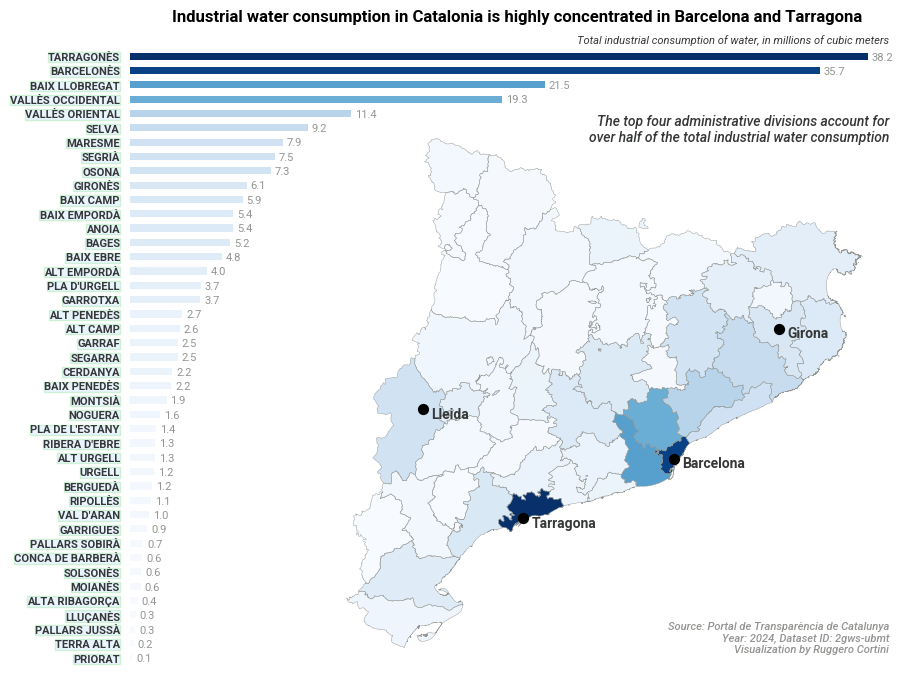

In [14]:
fig, ax = plt.subplots(figsize=(10,8))

# 1. Normalize values
norm = mpl.colors.Normalize(
    vmin=s.min(),
    vmax=s.max()
)

# 2. Choose a colormap
cmap = mpl.cm.Blues  # we'll discuss palettes below

# 3. Map values to colors
colors = cmap(norm(s))

plot_df = s / 1e6
plot_df.plot(ax=ax, kind='barh', color=colors)

ax.set_ylabel("")
ax.tick_params(axis='both', which='both', left=False, bottom=False)
ax.set_xlabel("")
ax.set_xticklabels([])
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

bbox = dict(ec="limegreen", fc="xkcd:light blue", alpha=0.2, pad=0.1)
plt.setp(ax.get_yticklabels(), bbox=bbox, fontsize=8, fontweight='bold')

for i, val in enumerate(s.values):
    ax.text(val/1e6+0.2, i-0.25, f'{val/1e6:.1f}', fontsize=8, color='xkcd:grey')

ha = 0.98

ax.text(
    ha,
    1.01,
    "Total industrial consumption of water, in millions of cubic meters",
    transform=ax.transAxes,
    color='xkcd:dark grey',
    fontsize=8,
    style='italic',
    ha='right'
    )

ax.text(
    ha,
    0.02,
    "Source: Portal de Transparència de Catalunya\nYear: 2024, Dataset ID: 2gws-ubmt\nVisualization by Ruggero Cortini",
    transform=ax.transAxes,
    color='xkcd:grey',
    fontsize=8,
    style='italic',
    fontweight='medium',
    ha='right'
    )

ax.text(
    ha,
    0.85,
    "The top four administrative divisions account for\nover half of the total industrial water consumption",
    transform=ax.transAxes,
    color='xkcd:dark grey',
    fontsize=10,
    style='italic',
    fontweight='medium',
    ha='right'
    )

ax.set_title(
    "Industrial water consumption in Catalonia is highly concentrated in Barcelona and Tarragona",
    pad=20,
    fontweight='bold'
)

## MAP OF CATALONIA

# These are in unitless percentages of the figure size. (0,0 is bottom left)
left, bottom, width, height = [0.25, 0.1, 0.7, 0.7]
ax2 = fig.add_axes([left, bottom, width, height])

# prepare data to plot
plot_df = gdf.query('any == 2024')

# plot Cloropleth
plot_df.plot(
    ax=ax2,
    column='activitats_econ_miques_i',
    cmap=cmap
)

# plot contours of the Comarques
comarques.plot(
    ax=ax2,
    facecolor="none",
    edgecolor="xkcd:grey",
    linewidth=0.3
)

barcelona_coords = [2.171474, 41.389160]
girona_coords = [2.819219, 41.986706]
tarragona_coords = [1.245463, 41.116712]
lleida_coords = [0.625974, 41.617497]

city_coords = {
    'Barcelona' : barcelona_coords,
    'Girona' : girona_coords,
    'Tarragona' : tarragona_coords,
    'Lleida' : lleida_coords
}

for city, coords in city_coords.items():
    ax2.scatter(coords[0], coords[1], color='k', s=50)
    ax2.text(coords[0]+0.05, coords[1]-0.04, city, color='xkcd:dark gray', fontsize=10, fontweight='bold')

# remove spines
plt.axis('off')

fig.savefig("industrial_consumption_viz.jpg", bbox_inches='tight')
plt.show()